# 06 — Pre-Modeling EDA

Central question: **what is a news headline classifier actually learning?**

This notebook establishes whether Fox/NBC differences are driven by *topic coverage* or *writing style* — a distinction that motivates all downstream modeling and analysis decisions.

Sections:
1. Publication volume over time
2. Headline length distribution
3. Posting hour and day-of-week patterns
4. Punctuation and style signals
5. URL-extracted category distribution
6. BERTopic — data-driven topic modeling
7. Style signals within shared topics (key finding)

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

FOX_COLOR = '#E81B23'
NBC_COLOR = '#2A5EAC'
ALPHA = 0.75

In [33]:
df = pd.read_csv('../data/processed/combined_base_data.csv')

df['datetime_posted'] = pd.to_datetime(df['datetime_posted'], utc=True, errors='coerce')
df['date'] = df['datetime_posted'].dt.date
df['year_month'] = df['datetime_posted'].dt.to_period('M')
df['hour'] = df['datetime_posted'].dt.hour
df['dow'] = df['datetime_posted'].dt.day_name()

fox = df[df['is_fox'] == 1].copy()
nbc = df[df['is_fox'] == 0].copy()

print(f'Fox: {len(fox):,} articles')
print(f'NBC: {len(nbc):,} articles')
print(f'Date range: {df["datetime_posted"].min().date()} to {df["datetime_posted"].max().date()}')
print(f'Missing titles: {df["title"].isna().sum()}')
print(f'Missing datetimes: {df["datetime_posted"].isna().sum()}')

Fox: 2,000 articles
NBC: 1,805 articles
Date range: 2020-01-06 to 2026-03-13
Missing titles: 4
Missing datetimes: 1409


## 1 — Publication Volume Over Time

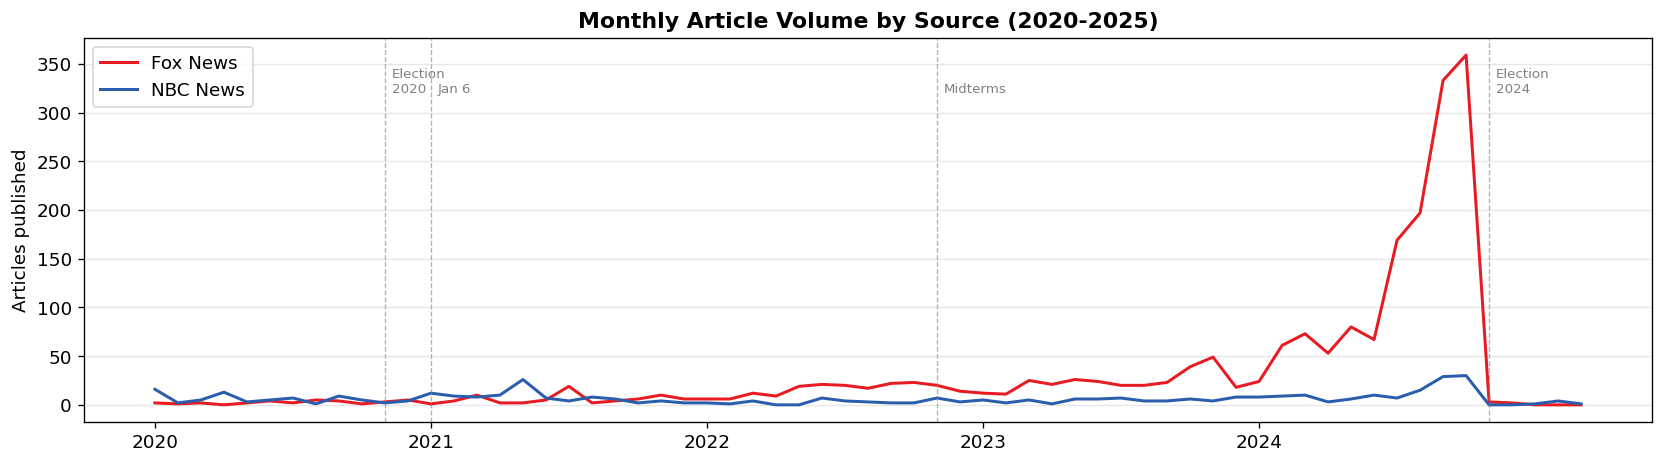

In [34]:
df_t = df.dropna(subset=['datetime_posted']).copy()
fox_t = df_t[df_t['is_fox'] == 1]
nbc_t = df_t[df_t['is_fox'] == 0]

fox_monthly = fox_t.groupby('year_month').size()
nbc_monthly = nbc_t.groupby('year_month').size()

all_periods = fox_monthly.index.union(nbc_monthly.index)
fox_monthly = fox_monthly.reindex(all_periods, fill_value=0)
nbc_monthly = nbc_monthly.reindex(all_periods, fill_value=0)
x = range(len(all_periods))
x_labels = [str(p) for p in all_periods]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(x, fox_monthly.values, color=FOX_COLOR, label='Fox News', linewidth=1.8)
ax.plot(x, nbc_monthly.values, color=NBC_COLOR, label='NBC News', linewidth=1.8)

events = {
    '2020-11': 'Election\n2020',
    '2021-01': 'Jan 6',
    '2022-11': 'Midterms',
    '2024-11': 'Election\n2024',
}
for period_str, label in events.items():
    matches = [i for i, p in enumerate(x_labels) if p == period_str]
    if matches:
        ax.axvline(matches[0], color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.text(matches[0] + 0.3, ax.get_ylim()[1] * 0.85, label, fontsize=8, color='gray')

year_ticks = [i for i, p in enumerate(x_labels) if p.endswith('-01')]
year_labels = [p[:4] for p in x_labels if p.endswith('-01')]
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels)
ax.set_title('Monthly Article Volume by Source (2020-2025)', fontweight='bold')
ax.set_ylabel('Articles published')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 2 — Headline Length Distribution

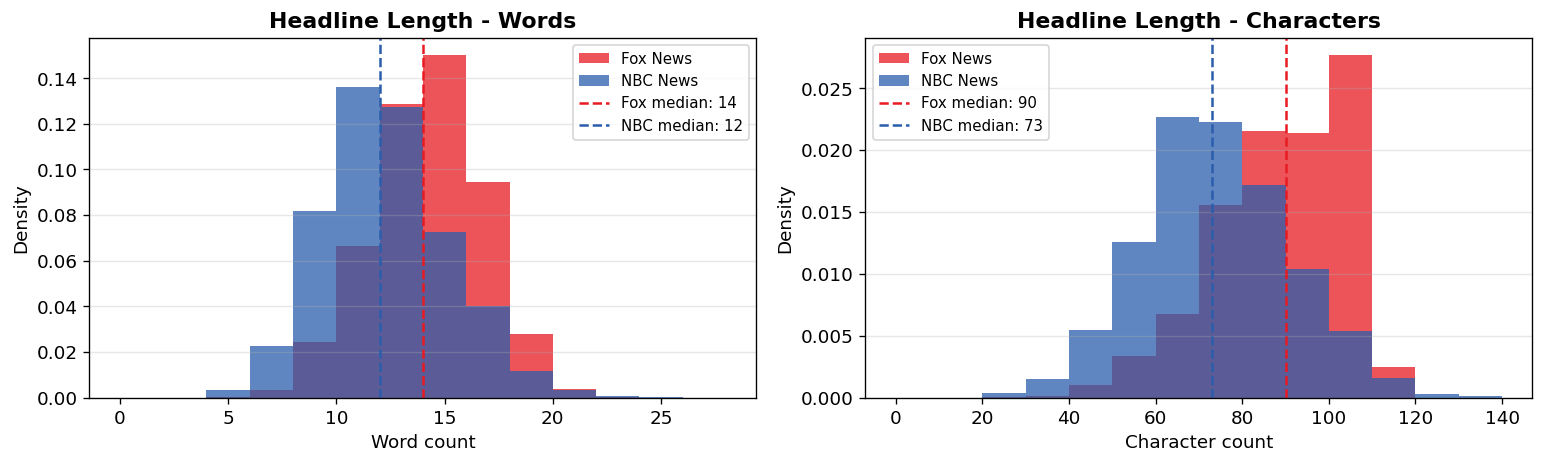

--- Summary stats ---

word_count:
         count  mean  std  min   25%   50%   75%   max
is_fox                                                
0       1801.0  11.8  2.9  4.0  10.0  12.0  14.0  24.0
1       2000.0  13.8  2.6  5.0  12.0  14.0  16.0  22.0

char_count:
         count  mean   std   min   25%   50%    75%    max
is_fox                                                    
0       1801.0  73.7  17.2  21.0  62.0  73.0   85.0  139.0
1       2000.0  88.7  15.1  29.0  78.0  90.0  102.0  110.0


In [35]:
df_h = df.dropna(subset=['title']).copy()
df_h['word_count'] = df_h['title'].str.split().str.len()
df_h['char_count'] = df_h['title'].str.len()

fox_h = df_h[df_h['is_fox'] == 1]
nbc_h = df_h[df_h['is_fox'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label in zip(axes, ['word_count', 'char_count'], ['Word count', 'Character count']):
    bins = range(0, df_h[col].max() + 5, 2 if col == 'word_count' else 10)
    ax.hist(fox_h[col], bins=bins, color=FOX_COLOR, alpha=ALPHA, label='Fox News', density=True)
    ax.hist(nbc_h[col], bins=bins, color=NBC_COLOR, alpha=ALPHA, label='NBC News', density=True)
    ax.axvline(fox_h[col].median(), color=FOX_COLOR, linestyle='--', linewidth=1.5,
               label=f'Fox median: {fox_h[col].median():.0f}')
    ax.axvline(nbc_h[col].median(), color=NBC_COLOR, linestyle='--', linewidth=1.5,
               label=f'NBC median: {nbc_h[col].median():.0f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_title('Headline Length - Words', fontweight='bold')
axes[1].set_title('Headline Length - Characters', fontweight='bold')
plt.tight_layout()
plt.show()

print('--- Summary stats ---')
for col in ['word_count', 'char_count']:
    print(f'\n{col}:')
    print(df_h.groupby('is_fox')[col].describe().round(1).to_string())

## 3 — Posting Hour and Day-of-Week Patterns

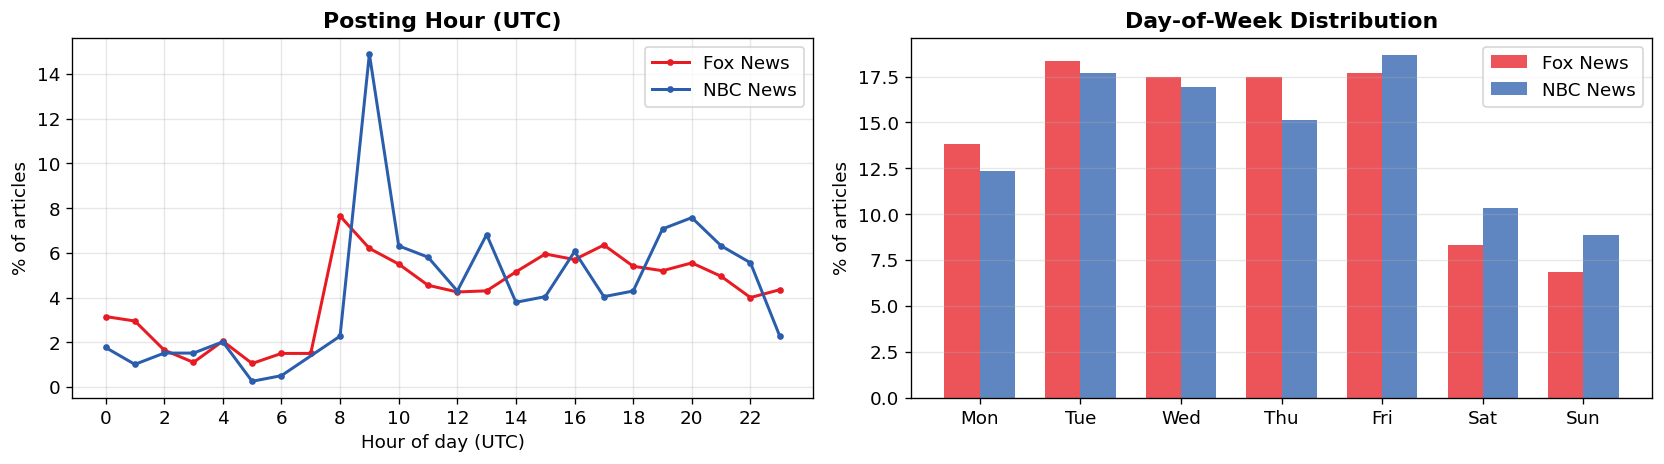

In [36]:
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fox_hour = fox_t.groupby('hour').size() / len(fox_t) * 100
nbc_hour = nbc_t.groupby('hour').size() / len(nbc_t) * 100

fox_dow = fox_t['dow'].value_counts().reindex(DOW_ORDER) / len(fox_t) * 100
nbc_dow = nbc_t['dow'].value_counts().reindex(DOW_ORDER) / len(nbc_t) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(fox_hour.index, fox_hour.values, color=FOX_COLOR, label='Fox News',
        linewidth=1.8, marker='o', markersize=3)
ax.plot(nbc_hour.index, nbc_hour.values, color=NBC_COLOR, label='NBC News',
        linewidth=1.8, marker='o', markersize=3)
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('% of articles')
ax.set_title('Posting Hour (UTC)', fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
x = np.arange(len(DOW_ORDER))
width = 0.35
ax.bar(x - width/2, fox_dow.values, width, color=FOX_COLOR, alpha=ALPHA, label='Fox News')
ax.bar(x + width/2, nbc_dow.values, width, color=NBC_COLOR, alpha=ALPHA, label='NBC News')
ax.set_xticks(x)
ax.set_xticklabels([d[:3] for d in DOW_ORDER])
ax.set_ylabel('% of articles')
ax.set_title('Day-of-Week Distribution', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4 — Punctuation and Style Signals

Fox News is known for using scare quotes around words to editorialize (e.g., *'crisis'*, *'expert'*). These are style signals the classifier may learn to exploit, independent of topic.

Note: double quotes were tested but came back at 0% for both outlets (news headlines use single quotes for attribution), so they are excluded here.

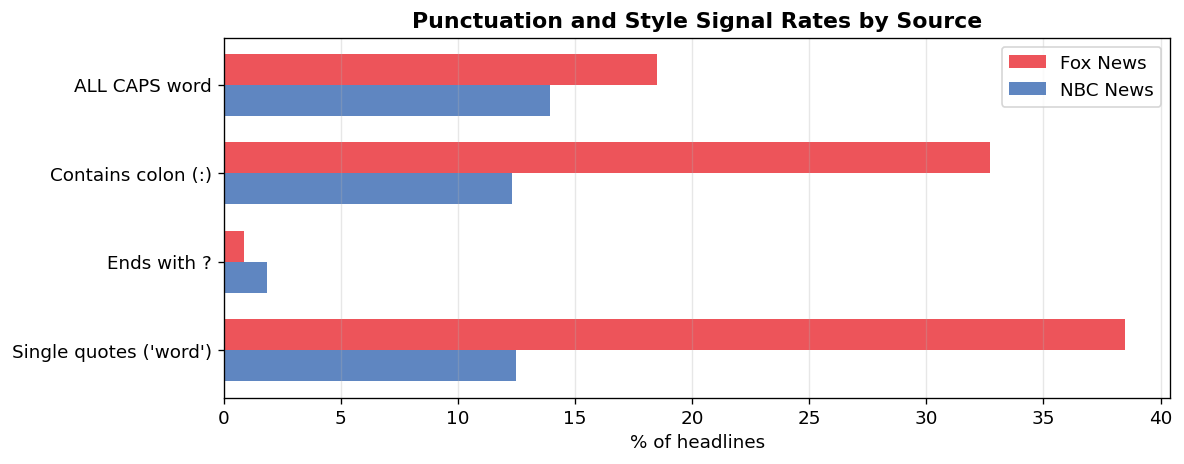

                        Fox News  NBC News
Single quotes ('word')      38.5      12.5
Ends with ?                  0.8       1.8
Contains colon (:)          32.7      12.3
ALL CAPS word               18.5      13.9


In [37]:
# df_s is the base style dataframe, reused in section 7
# word_count and char_count are included here so the section 7 groupby works
df_s = df.dropna(subset=['title']).copy()
df_s['word_count'] = df_s['title'].str.split().str.len()
df_s['char_count'] = df_s['title'].str.len()
df_s['has_single_quotes'] = df_s['title'].str.contains(r"'[^']{1,40}'", regex=True)
df_s['has_question'] = df_s['title'].str.endswith('?')
df_s['has_colon'] = df_s['title'].str.contains(r':', regex=False)
df_s['has_allcaps'] = df_s['title'].str.contains(r'\b[A-Z]{3,}\b', regex=True)

style_cols = {
    'has_single_quotes': "Single quotes ('word')",
    'has_question': 'Ends with ?',
    'has_colon': 'Contains colon (:)',
    'has_allcaps': 'ALL CAPS word',
}

rates = pd.DataFrame({
    'Fox News': [df_s[df_s['is_fox']==1][c].mean()*100 for c in style_cols],
    'NBC News': [df_s[df_s['is_fox']==0][c].mean()*100 for c in style_cols],
}, index=style_cols.values())

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(rates))
width = 0.35
ax.barh(x + width/2, rates['Fox News'], width, color=FOX_COLOR, alpha=ALPHA, label='Fox News')
ax.barh(x - width/2, rates['NBC News'], width, color=NBC_COLOR, alpha=ALPHA, label='NBC News')
ax.set_yticks(x)
ax.set_yticklabels(rates.index)
ax.set_xlabel('% of headlines')
ax.set_title('Punctuation and Style Signal Rates by Source', fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(rates.round(1).to_string())

In [38]:
# Spot-check: confirm the single-quote pattern is scare quotes (Fox) vs genuine attribution (NBC)
print('=== Fox single-quote examples ===')
for t in df_s[(df_s['is_fox']==1) & (df_s['has_single_quotes'])]['title'].sample(5, random_state=42):
    print(' ', t)

print('\n=== NBC single-quote examples ===')
for t in df_s[(df_s['is_fox']==0) & (df_s['has_single_quotes'])]['title'].sample(5, random_state=42):
    print(' ', t)

=== Fox single-quote examples ===
  Kirby slams Hamas chief Sinwar as 'the major obstacle' to cease-fire, hostage release deal with Israel
  Brian Stelter defends 2020 media coverage of Hunter Biden laptop story: We never labeled it 'disinformation'
  Major CNN Trump critic Brian Stelter admits Trump 'was funny' during Al Smith Dinner: 'A few great jokes'
  'Biggest medical fraud of our time': Riley Gaines dives into the heart of gender-affirming care epidemic
  Left 'just died' with the emergence of 'Kamala Harris Democrats,' says CNN's Van Jones

=== NBC single-quote examples ===
  'They're not here to hurt me': Former aide says Trump knew Jan. 6 crowd was armed
  Israeli forces begin 'targeted' ground operation in Lebanon, IDF says
  How 'sex addiction' has historically been used to absolve white men
  Stewart Rhodes wrote message to Trump after Jan. 6 calling on him to 'save the Republic' and arrest members of Congress
  Inside Egypt's 3,000-year-old 'lost golden city'


## 5 — URL-Extracted Category Distribution

Categories extracted from the URL path segment (e.g., `foxnews.com/politics/...` -> `politics`). These reflect each outlet's *own editorial taxonomy*, not a neutral topic label — so cross-outlet comparisons should be interpreted carefully. Section 6 addresses this limitation with outlet-agnostic topic modeling.

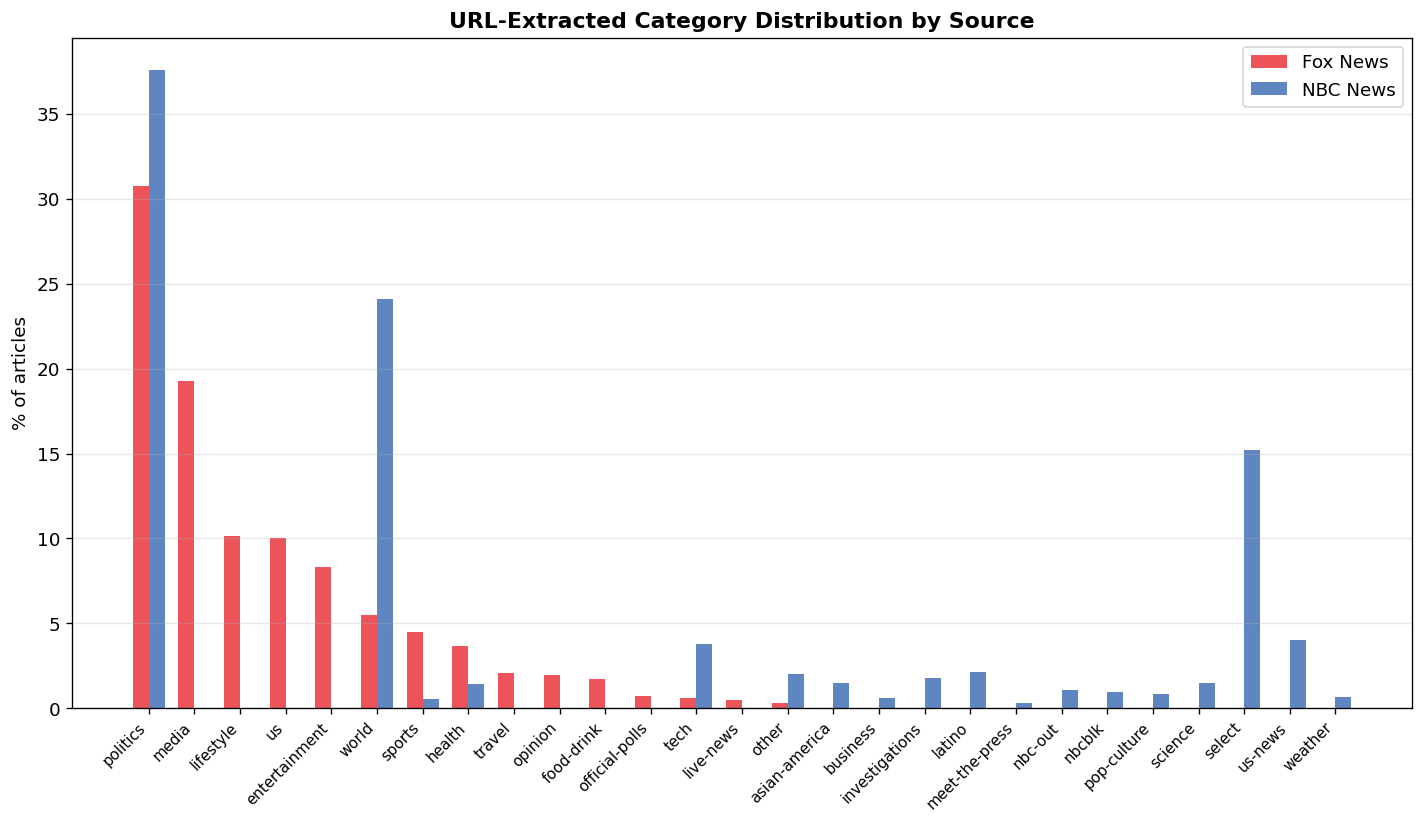

In [39]:
fox_cat = fox['category'].value_counts(normalize=True) * 100
nbc_cat = nbc['category'].value_counts(normalize=True) * 100

all_cats = sorted(set(fox_cat.index) | set(nbc_cat.index))
fox_vals = [fox_cat.get(c, 0) for c in all_cats]
nbc_vals = [nbc_cat.get(c, 0) for c in all_cats]

order = sorted(range(len(all_cats)), key=lambda i: fox_vals[i], reverse=True)
all_cats = [all_cats[i] for i in order]
fox_vals = [fox_vals[i] for i in order]
nbc_vals = [nbc_vals[i] for i in order]

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(all_cats))
width = 0.35
ax.bar(x - width/2, fox_vals, width, color=FOX_COLOR, alpha=ALPHA, label='Fox News')
ax.bar(x + width/2, nbc_vals, width, color=NBC_COLOR, alpha=ALPHA, label='NBC News')
ax.set_xticks(x)
ax.set_xticklabels(all_cats, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('% of articles')
ax.set_title('URL-Extracted Category Distribution by Source', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
cat_df = pd.DataFrame({'fox_pct': fox_vals, 'nbc_pct': nbc_vals}, index=all_cats)
cat_df['divergence'] = (cat_df['fox_pct'] - cat_df['nbc_pct']).abs()

print('=== Most divergent categories ===')
print(cat_df.sort_values('divergence', ascending=False).head(10).round(1).to_string())

print('\n=== Fox-only categories ===')
print(cat_df[cat_df['nbc_pct'] == 0].sort_values('fox_pct', ascending=False).round(1).to_string())

print('\n=== NBC-only categories ===')
print(cat_df[cat_df['fox_pct'] == 0].sort_values('nbc_pct', ascending=False).round(1).to_string())

=== Most divergent categories ===
               fox_pct  nbc_pct  divergence
media             19.2      0.0        19.2
world              5.5     24.1        18.6
select             0.0     15.2        15.2
lifestyle         10.2      0.0        10.2
us                10.0      0.0        10.0
entertainment      8.3      0.0         8.3
politics          30.8     37.6         6.9
us-news            0.0      4.0         4.0
sports             4.5      0.6         3.9
tech               0.6      3.8         3.2

=== Fox-only categories ===
                fox_pct  nbc_pct  divergence
media              19.2      0.0        19.2
lifestyle          10.2      0.0        10.2
us                 10.0      0.0        10.0
entertainment       8.3      0.0         8.3
travel              2.1      0.0         2.1
opinion             2.0      0.0         2.0
food-drink          1.8      0.0         1.8
official-polls      0.7      0.0         0.7
live-news           0.5      0.0         0.5

==

## 6 — BERTopic: Data-Driven Topic Modeling

URL categories reflect each outlet's own editorial taxonomy, raising the concern that Fox and NBC might label the same stories differently. BERTopic addresses this by deriving topics from headline text itself — both outlets receive labels from the same neutral system.

**Pipeline:**
1. Embed headlines with `all-MiniLM-L6-v2` (semantic similarity maps to geometric proximity)
2. Reduce 384-dim embeddings to 5 dims with UMAP (makes clustering tractable)
3. Cluster with HDBSCAN (density-based; labels low-confidence docs as -1 outliers)
4. Extract characteristic words per cluster with c-TF-IDF

In [24]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer

df_bert = df.dropna(subset=['title']).copy()
headlines = df_bert['title'].tolist()

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6647.69it/s]


In [25]:
# Pre-compute embeddings separately so we can rerun BERTopic with
# different settings without recomputing (~30-60s on CPU)
embeddings = embedding_model.encode(headlines, show_progress_bar=True)

Batches: 100%|██████████| 119/119 [00:03<00:00, 37.18it/s]


In [ ]:
# Test different n_components with a stable random state - using 5 because it's standard and shows decent stats
results = {}
for n in [3, 5, 8, 10]:
    umap_model = UMAP(n_components=n, random_state=42)
    hdbscan_model = HDBSCAN(min_cluster_size=30, prediction_data=True)
    m = BERTopic(embedding_model=embedding_model,
                 umap_model=umap_model,
                 hdbscan_model=hdbscan_model,
                 nr_topics='auto', verbose=False)
    t, _ = m.fit_transform(headlines, embeddings)
    n_topics = len(set(t)) - 1  # exclude -1
    outlier_pct = (pd.Series(t) == -1).mean() * 100
    results[n] = {'n_topics': n_topics, 'outlier_pct': round(outlier_pct, 1)}
    print(f'n_components={n}: {n_topics} topics, {outlier_pct:.1f}% outliers')

n_components=3: 8 topics, 33.0% outliers
n_components=5: 13 topics, 23.1% outliers
n_components=8: 3 topics, 2.4% outliers
n_components=10: 14 topics, 27.1% outliers


In [27]:
# Fit BERTopic with the chosen n_components and stable random state
umap_model = UMAP(n_components=5, random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=30, prediction_data=True)
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    nr_topics='auto',    # let HDBSCAN find the natural cluster count
    verbose=True
)

topics, probs = topic_model.fit_transform(headlines, embeddings)

2026-05-05 04:40:03,280 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-05 04:40:18,364 - BERTopic - Dimensionality - Completed ✓
2026-05-05 04:40:18,365 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-05 04:40:18,472 - BERTopic - Cluster - Completed ✓
2026-05-05 04:40:18,473 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-05 04:40:18,520 - BERTopic - Representation - Completed ✓
2026-05-05 04:40:18,521 - BERTopic - Topic reduction - Reducing number of topics
2026-05-05 04:40:18,525 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-05 04:40:18,568 - BERTopic - Representation - Completed ✓
2026-05-05 04:40:18,569 - BERTopic - Topic reduction - Reduced number of topics from 14 to 14


In [28]:
topic_info = topic_model.get_topic_info()
print(topic_info[['Topic', 'Count', 'Name', 'Representation']].to_string())

    Topic  Count                              Name                                                                        Representation
0      -1    877                   -1_to_in_the_of                                     [to, in, the, of, on, for, trump, and, as, after]
1       0    762       0_harris_trump_kamala_biden                              [harris, trump, kamala, biden, to, in, the, on, for, of]
2       1    598       1_israel_hamas_gaza_israeli                      [israel, hamas, gaza, israeli, in, of, netanyahu, to, iran, and]
3       2    347      2_best_2026_select_according                      [best, 2026, select, according, nbc, the, to, experts, for, and]
4       3    334    3_trump_jan_assassination_case            [trump, jan, assassination, case, capitol, court, attempt, judge, to, who]
5       4    154       4_taylor_swift_willis_bruce                 [taylor, swift, willis, bruce, with, after, his, cowell, simon, liam]
6       5    137        5_russia_korea_no

In [ ]:
# Look at fox vs nbc distribution across topics to see if any are heavily skewed toward one source
df_bert['topic_id'] = topics
check = df_bert.groupby(['topic_id', 'is_fox']).size().unstack(fill_value=0)
check.columns = ['NBC', 'Fox']
check['fox_pct'] = (check['Fox'] / (check['Fox'] + check['NBC']) * 100).round(1)
print(check)

          NBC  Fox  fox_pct
topic_id                   
-1        377  500     57.0
 0        219  543     71.3
 1        432  166     27.8
 2        279   68     19.6
 3        215  119     35.6
 4         22  132     85.7
 5        113   24     17.5
 6         37   93     71.5
 7          1  125     99.2
 8         54   42     43.8
 9          8   67     89.3
 10        39   32     45.1
 11         2   46     95.8
 12         3   43     93.5


In [40]:
# Assign human-readable labels after inspecting the keywords above
# Update these if your topic numbers differ from what was found during development
topic_labels = {
    -1: 'Outlier',
     0: 'US Politics / Election',
     1: 'Israel-Gaza Conflict',
     2: 'NBC Select (Product Reviews)',
     3: 'Trump Legal / Jan 6',
     4: 'Fox: Jan 6 / Assassination Attempt',
     5: 'Russia / Ukraine / China',
     6: 'Crime / Immigration',
     7: 'Fox: History Series',
     8: 'Abortion / Reproductive Rights',
     9: 'Fox: Transgender Sports',
    10: 'Hurricanes / Weather',
    11: 'Fox: Health Studies',
    12: 'Fox: Biden Climate Policy',
}

df_bert['topic_id'] = topics
df_bert['topic_label'] = df_bert['topic_id'].map(topic_labels)

# Merge topic assignments back onto df_s1 (copy of df_s) for the style analysis in section 7
df_s1 = df_s.copy()
df_s1 = df_s1.merge(
    df_bert[['url', 'topic_id', 'topic_label']],
    on='url', how='left'
)

In [41]:
df_s1

,url,title,subtitle,author,datetime_posted,category,is_fox,date,year_month,hour,dow,word_count,char_count,has_single_quotes,has_question,has_colon,has_allcaps,topic_id,topic_label
0,https://www.foxnews.com/politics/blinken-meets...,"Blinken meets Qatar PM, says Israeli actions a...",Blinken stressed the importance of protecting ...,Timothy H.J. Nerozzi,2023-10-13 18:06:08+00:00,politics,1,2023-10-13,2023-10,18.0,Friday,17,107,True,False,False,False,1,Israel-Gaza Conflict
1,https://www.foxnews.com/entertainment/bruce-wi...,"Bruce Willis, Demi Moore avoided doing one thi...",Demi Moore and Bruce Willis have been divorced...,Lauryn Overhultz,2024-10-18 19:56:05+00:00,entertainment,1,2024-10-18,2024-10,19.0,Friday,12,82,False,False,False,False,4,Fox: Jan 6 / Assassination Attempt
2,https://www.foxnews.com/media/the-view-co-host...,"'The View' co-host, CNN commentator Ana Navarr...","'It’s just such a mind-blowing moment,' Navarr...",Kristine Parks,2024-08-20 01:00:35+00:00,media,1,2024-08-20,2024-08,1.0,Tuesday,15,97,True,False,False,True,0,US Politics / Election
3,https://www.foxnews.com/entertainment/emily-bl...,Emily Blunt says her ‘toes curl’ when people t...,Blunt and John Krasinski share two daughters; ...,Lauryn Overhultz,2023-06-09 17:55:28+00:00,entertainment,1,2023-06-09,2023-06,17.0,Friday,22,107,True,False,True,False,-1,Outlier
4,https://www.foxnews.com/lifestyle/jack-carrs-e...,Jack Carr recalls Gen. Eisenhower's D-Day memo...,Bestselling author recalls Gen. Eisenhower's s...,Jack Carr,2024-06-06 08:30:24+00:00,lifestyle,1,2024-06-06,2024-06,8.0,Thursday,12,82,True,False,False,False,-1,Outlier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3796,https://www.nbcnews.com/politics/2024-election...,Trump's lawyers seek post-Election Day delay f...,Former President Donald Trump's legal team on ...,Ryan J. Reilly | Daniel Barnes,NaT,politics,0,NaT,NaT,NaN,NaN,16,112,False,False,False,False,3,Trump Legal / Jan 6
3797,https://www.nbcnews.com/select/shopping/best-a...,"The Best Treatments for Acne Scars, According ...",Acne scars and hyperpigmentation can be hard t...,Mili Godio | Nicole Saunders,NaT,select,0,NaT,NaT,NaN,NaN,12,76,False,False,False,True,2,NBC Select (Product Reviews)
3798,https://www.nbcnews.com/select/shopping/best-v...,7 Best Vegetarian and Vegan Meal Delivery Serv...,Find some of the best meal delivery services w...,Mili Godio,NaT,select,0,NaT,NaT,NaN,NaN,10,58,False,False,False,False,2,NBC Select (Product Reviews)
3799,https://www.nbcnews.com/politics/2024-election...,Trump says presidential civilian award is 'bet...,Former President Donald Trump lauded Miriam Ad...,Jake Traylor | Ginger Gibson | Katherine Koret...,NaT,politics,0,NaT,NaT,NaN,NaN,19,122,True,False,False,False,-1,Outlier


In [42]:
# Fox vs NBC distribution across BERTopic topics
df_topics = df_bert[df_bert['topic_id'] != -1].copy()

topic_dist = df_topics.groupby(['topic_label', 'is_fox']).size().unstack(fill_value=0)
topic_dist.columns = ['NBC News', 'Fox News']
topic_dist['NBC_pct'] = topic_dist['NBC News'] / topic_dist['NBC News'].sum() * 100
topic_dist['Fox_pct'] = topic_dist['Fox News'] / topic_dist['Fox News'].sum() * 100
topic_dist['divergence'] = (topic_dist['Fox_pct'] - topic_dist['NBC_pct']).abs()

print(topic_dist.sort_values('divergence', ascending=False).round(1).to_string())

                                    NBC News  Fox News  NBC_pct  Fox_pct  divergence
topic_label                                                                         
US Politics / Election                   219       543     15.4     36.2        20.8
Israel-Gaza Conflict                     432       166     30.3     11.1        19.3
NBC Select (Product Reviews)             279        68     19.6      4.5        15.1
Fox: History Series                        1       125      0.1      8.3         8.3
Fox: Jan 6 / Assassination Attempt        22       132      1.5      8.8         7.3
Trump Legal / Jan 6                      215       119     15.1      7.9         7.2
Russia / Ukraine / China                 113        24      7.9      1.6         6.3
Fox: Transgender Sports                    8        67      0.6      4.5         3.9
Crime / Immigration                       37        93      2.6      6.2         3.6
Fox: Health Studies                        2        46      0.1  

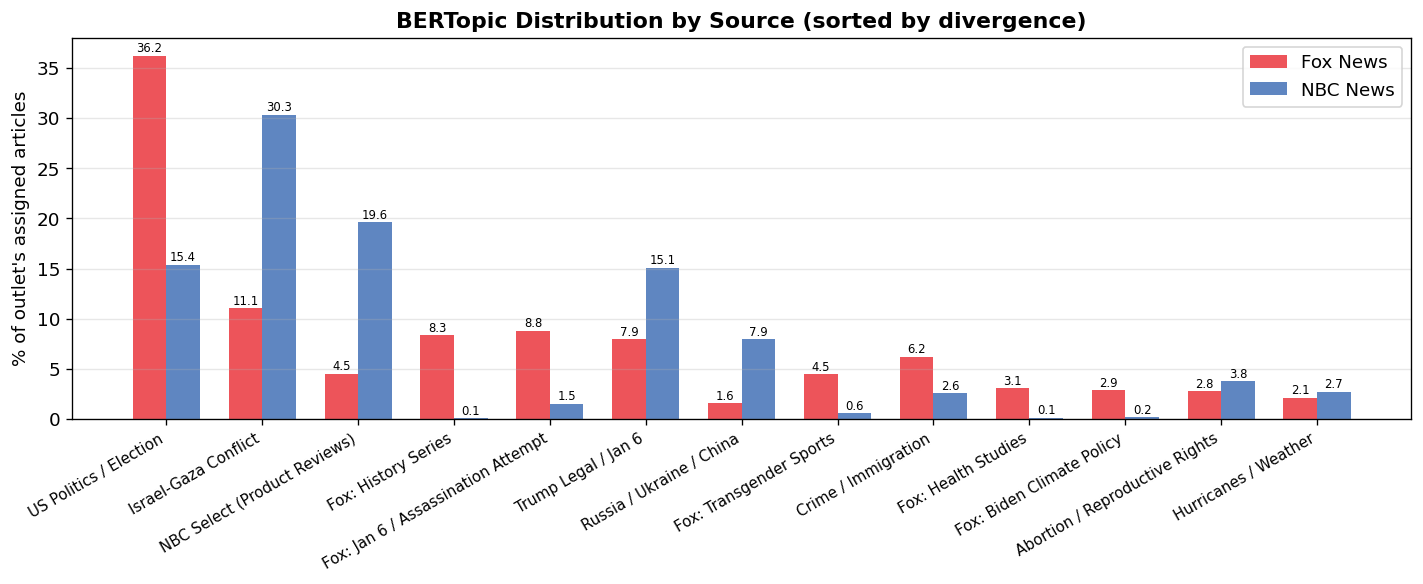

In [53]:
plot_topics = topic_dist.sort_values('divergence', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(plot_topics))
width = 0.35

fox_bars = ax.bar(x - width/2, plot_topics['Fox_pct'], width, color=FOX_COLOR, alpha=ALPHA, label='Fox News')
nbc_bars = ax.bar(x + width/2, plot_topics['NBC_pct'], width, color=NBC_COLOR, alpha=ALPHA, label='NBC News')

ax.bar_label(fox_bars, fmt='%.1f', fontsize=7, padding=0.5, rotation=0)
ax.bar_label(nbc_bars, fmt='%.1f', fontsize=7, padding=0.5, rotation=0)

ax.set_xticks(x)
ax.set_xticklabels(plot_topics.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel("% of outlet's assigned articles")
ax.set_title('BERTopic Distribution by Source (sorted by divergence)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7 — Style Signals Within Shared Topics

**Key finding:** Even when both outlets cover the same BERTopic-assigned subject matter, Fox consistently shows higher single-quote and colon usage. This is evidence that the classifier is learning *style*, not just *topic coverage*.

We use BERTopic labels here rather than URL categories so the comparison is outlet-agnostic — both outlets receive topic labels from the same system applied to the headline text itself.

In [55]:
# Select topics with meaningful representation in both outlets
topic_counts = df_topics.groupby(['topic_label', 'is_fox']).size().unstack(fill_value=0)
topic_counts.columns = ['NBC', 'Fox']
shared_topics = topic_counts[(topic_counts['NBC'] > 10) & (topic_counts['Fox'] > 10)].index.tolist()
print('Shared topics:', shared_topics)

df_shared = df_s1[df_s1['topic_label'].isin(shared_topics)].copy()

style_by_topic = df_shared.groupby(['topic_label', 'is_fox']).agg(
    n=('title', 'count'),
    avg_words=('word_count', 'mean'),
    pct_single_quotes=('has_single_quotes', 'mean'),
    pct_question=('has_question', 'mean'),
    pct_colon=('has_colon', 'mean'),
).round(3)

print('\n=== Style signals within shared topics ===')
print(style_by_topic.to_string())

Shared topics: ['Abortion / Reproductive Rights', 'Crime / Immigration', 'Fox: Jan 6 / Assassination Attempt', 'Hurricanes / Weather', 'Israel-Gaza Conflict', 'NBC Select (Product Reviews)', 'Russia / Ukraine / China', 'Trump Legal / Jan 6', 'US Politics / Election']

=== Style signals within shared topics ===
                                             n  avg_words  pct_single_quotes  pct_question  pct_colon
topic_label                        is_fox                                                            
Abortion / Reproductive Rights     0        54     11.907              0.111         0.000      0.111
                                   1        42     13.405              0.429         0.000      0.262
Crime / Immigration                0        37     13.486              0.162         0.000      0.081
                                   1        93     13.731              0.312         0.000      0.409
Fox: Jan 6 / Assassination Attempt 0        22     11.227              0.136

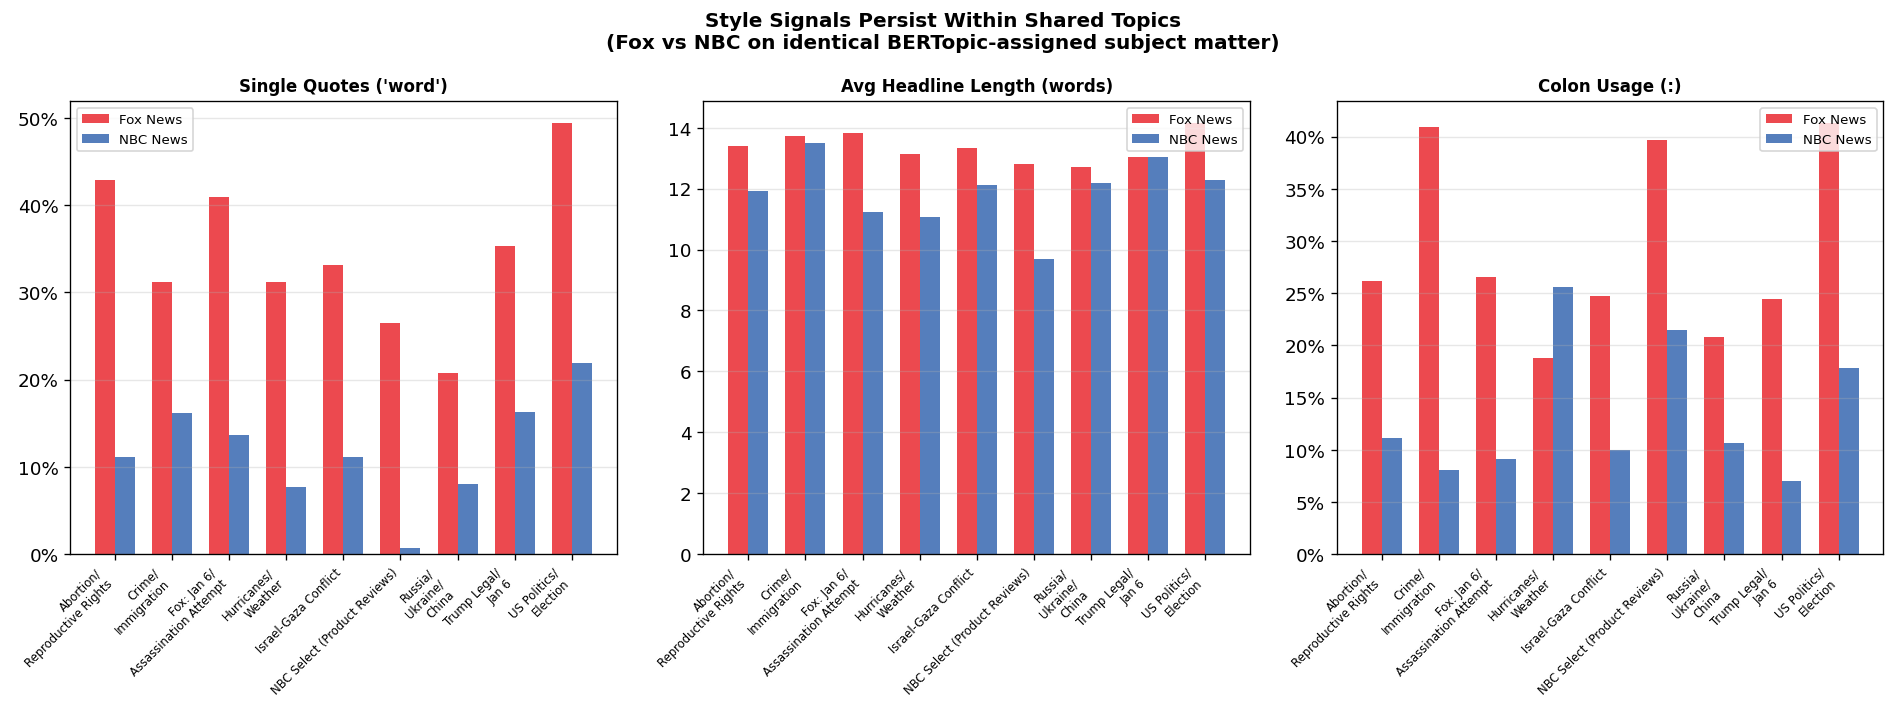

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metrics = {
    'pct_single_quotes': "Single Quotes ('word')",
    'avg_words': 'Avg Headline Length (words)',
    'pct_colon': 'Colon Usage (:)',
}

short_labels = [t.replace(' / ', '/\n') for t in shared_topics]

for ax, (metric, metric_label) in zip(axes, metrics.items()):
    fox_vals = [style_by_topic.loc[(t, 1), metric] for t in shared_topics]
    nbc_vals = [style_by_topic.loc[(t, 0), metric] for t in shared_topics]

    x = np.arange(len(shared_topics))
    width = 0.35
    ax.bar(x - width/2, fox_vals, width, color=FOX_COLOR, alpha=0.8, label='Fox News')
    ax.bar(x + width/2, nbc_vals, width, color=NBC_COLOR, alpha=0.8, label='NBC News')
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=7, rotation=45, ha='right')
    ax.set_title(metric_label, fontweight='bold', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)  # inside loop — fixed indentation

    if metric in ['pct_single_quotes', 'pct_colon']:
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%')
        )

fig.suptitle(
    'Style Signals Persist Within Shared Topics\n'
    '(Fox vs NBC on identical BERTopic-assigned subject matter)',
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.show()

## Key Takeaways
---

**Headline length** — Fox headlines are consistently longer: median 14 words vs NBC's 12, and mean character count of 88.7 vs 73.7. This is a reliable style signal. Fox tends toward the `Source: lengthy quoted claim` format which naturally inflates word count.

**Style signals** — The most striking finding. Fox uses single quotes in 38.5% of headlines vs NBC's 12.5%, and colons in 32.7% vs 12.3%. The spot-check examples confirm the Fox pattern is editorializing scare quotes ("'the major obstacle'", "'just died'") while NBC uses them for genuine attribution ("'They're not here to hurt me'"). ALL CAPS is 18.5% vs 13.9% — a smaller gap but consistent.

**URL categories** — `media` (19.2%) is Fox-only and `select` (15.2%) is NBC-only. These are structural artifacts of each outlet's content strategy rather than genuine topic coverage differences. `world` skews heavily NBC (24.1% vs 5.5%), which lines up with the BERTopic finding that Israel-Gaza is a predominantly NBC topic.

**BERTopic distribution** — The most analytically interesting section. Five topics are essentially outlet-exclusive: Fox: History Series (99.2% Fox), Fox: Health Studies (95.8%), Fox: Biden Climate Policy (93.5%), Fox: Transgender Sports (89.3%), and Fox: Jan 6 / Assassination Attempt (85.7%). On the NBC side, NBC Select product reviews (80.4% NBC) and Russia/Ukraine/China (82.5% NBC) are strong NBC signals. These represent content categories a classifier can exploit as spurious signals without learning anything meaningful about writing style.

**Within-topic style signals** — The key finding that makes this EDA stand out. Even controlling for topic using the outlet-agnostic BERTopic labels, Fox consistently shows higher single-quote rates across every shared topic — 42.9% vs 11.1% in Abortion/Reproductive Rights, 35.6% vs 15.1% in the Politics/Election topic, 44.4% vs 16.2% in Crime/Immigration. The colon gap holds similarly. This directly refutes the "it's just learning topic differences" critique — the style signal persists even when both outlets are covering identical subject matter.